In [41]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [10]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "Titanic-Dataset.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "yasserh/titanic-dataset",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

display(df.head())

C:\Users\HP\AppData\Local\Temp\ipykernel_7976\2379036946.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [12]:
print(df.columns)
#fare: the money pay to travel on transportation
#Survived: 0-died, 1-alive
#parch: number of people with u, (parent children)
#embarked: port city where passenger boarded (s = southampton, c = cherbourg, q = queenstown)
#SibSp: Siblings and Spouses
#cabin : cabin number

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')


In [22]:
print(df.shape)
print(df.count())

(891, 12)
PassengerId    891
Survived       891
Pclass         891
Name           891
Sex            891
Age            714
SibSp          891
Parch          891
Ticket         891
Fare           891
Cabin          204
Embarked       889
dtype: int64


In [31]:
print(df['Cabin'].isnull().sum())
print(df['Cabin'].unique())

687
<ArrowStringArray>
[          nan,         'C85',        'C123',         'E46',          'G6',
        'C103',         'D56',          'A6', 'C23 C25 C27',         'B78',
 ...
        'B102',         'B69',         'E49',         'C47',         'D28',
         'E17',         'A24',         'C50',         'B42',        'C148']
Length: 148, dtype: str


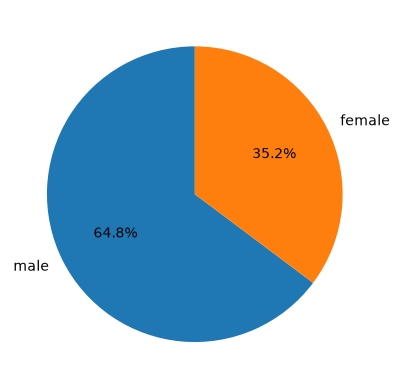

In [37]:
gender_counts = df['Sex'].value_counts()
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90)


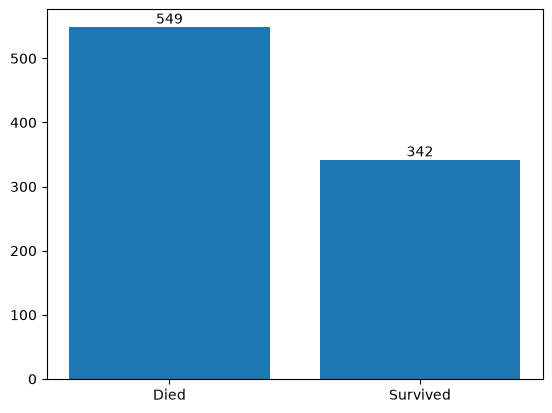

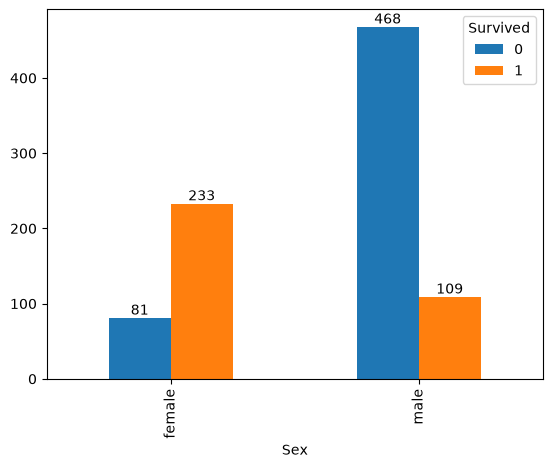

In [46]:
survived_counts = df['Survived'].value_counts()
# plt.subplot(1, 2, 1)
bars = plt.bar(['Died', 'Survived'], survived_counts)
# 2. Add the labels directly to those bars
plt.bar_label(bars)
survival_by_gender = pd.crosstab(df['Sex'], df['Survived'])
# plt.subplot(1, 2, 2)
ax = survival_by_gender.plot(kind='bar')
for container in ax.containers:
    ax.bar_label(container)

In [59]:
features = ['Pclass', 'Sex', 'Age', 'SibSp',
       'Parch', 'Fare', 'Embarked']
X = pd.get_dummies(df[features])
Y = df['Survived']
display(X.dtypes)
display(Y.shape)

Pclass          int64
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Sex_female       bool
Sex_male         bool
Embarked_C       bool
Embarked_Q       bool
Embarked_S       bool
dtype: object

(891,)

In [67]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [93]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size = 0.2, random_state = 55)

In [94]:
model = RandomForestClassifier()
model.fit(x_train, y_train)
y_predict = model.predict(x_test)

In [95]:
print(y_predict)

[1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 1 0 0 1
 0 0 1 0 1 0 0 1 0 0 1 0 0 0 1 0 0 1 0 1 0 0 1 0 1 1 0 1 1 0 0 1 0 1 1 1 1
 0 0 0 0 1 0 1 0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 1 1 0 0 0 0 0 0 0 0 1 1 0 0 1
 0 0 0 1 0 1 0 0 0 0 1 0 0 0 0 0 0 0 1 0 1 1 0 0 0 1 1 0 0 0 1 1 0 0 1 1 0
 0 1 0 0 1 0 1 1 1 0 0 0 0 0 0 1 0 0 0 1 0 0 1 0 1 0 1 0 0 1 0]


In [96]:
acc = accuracy_score(y_test, y_predict )
print(acc)

0.7988826815642458


In [97]:
print(classification_report( y_test, y_predict))

              precision    recall  f1-score   support

           0       0.80      0.89      0.84       110
           1       0.79      0.65      0.71        69

    accuracy                           0.80       179
   macro avg       0.80      0.77      0.78       179
weighted avg       0.80      0.80      0.79       179

